In [1]:
import sys
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, project_root)

results_dir = os.path.join(project_root, "results")
figures_dir = os.path.join(project_root, "figures")
processed_dir = os.path.join(project_root, "data", "processed")
os.makedirs(figures_dir, exist_ok=True)

target_encoder = pickle.load(open(os.path.join(processed_dir, "target_encoder.pkl"), "rb"))
class_names = list(target_encoder.classes_)

# Load ALL summary CSVs into one master table
summaries = []
for f in sorted(os.listdir(results_dir)):
    if f.endswith("_summary.csv"):
        df = pd.read_csv(os.path.join(results_dir, f))
        summaries.append(df)

master = pd.concat(summaries, ignore_index=True)

# Parse experiment name into model, feature_set, imbalance
parts = master["experiment"].str.rsplit("_", n=1, expand=True)
master["imbalance"] = parts[1]
remaining = parts[0].str.split("_", n=1, expand=True)
master["model"] = remaining[0].str.upper()
master["feature_set"] = remaining[1]

print(f"Total experiments: {len(master)}")
print(f"Models: {sorted(master['model'].unique())}")
print(f"Feature sets: {sorted(master['feature_set'].unique())}")
print(f"Imbalance: {sorted(master['imbalance'].unique())}")

# Show top 15 overall
print(f"\nTop 15 experiments by Macro F1:")
print(master.nlargest(15, "macro_f1")[["experiment", "macro_f1", "accuracy", "macro_recall"]].to_string(index=False))

Total experiments: 60
Models: ['DNN', 'LR', 'RF', 'SVM']
Feature sets: ['full-83', 'pca', 'top-10', 'top-20', 'top-30']
Imbalance: ['baseline', 'cost-sensitive', 'smote']

Top 15 experiments by Macro F1:
               experiment  macro_f1  accuracy  macro_recall
      rf_full-83_baseline  0.976337  0.998497      0.978751
          rf_pca_baseline  0.970819  0.997807      0.968209
             rf_pca_smote  0.970784  0.997888      0.972325
 rf_top-30_cost-sensitive  0.969737  0.998538      0.978075
    rf_pca_cost-sensitive  0.967254  0.997604      0.965593
         rf_full-83_smote  0.966825  0.998822      0.982323
          rf_top-30_smote  0.966509  0.998579      0.982019
       rf_top-30_baseline  0.965832  0.998619      0.980490
rf_full-83_cost-sensitive  0.965219  0.998538      0.979783
          rf_top-20_smote  0.960697  0.997198      0.971440
       rf_top-20_baseline  0.959253  0.997645      0.973629
          rf_top-10_smote  0.957380  0.997198      0.973697
 rf_top-20_cost-

In [2]:
# -- Master comparison: Macro F1 for every Model × Feature Set × Imbalance combo --
# This becomes the main results table in your report

pivot = master.pivot_table(
    values="macro_f1",
    index="feature_set",
    columns=["model", "imbalance"],
    aggfunc="first"
)

# Reorder rows and columns for clarity
row_order = ["full-83", "top-30", "top-20", "top-10", "pca"]
col_order = [
    ("DNN", "baseline"), ("DNN", "smote"), ("DNN", "cost-sensitive"),
    ("LR", "baseline"), ("LR", "smote"), ("LR", "cost-sensitive"),
    ("RF", "baseline"), ("RF", "smote"), ("RF", "cost-sensitive"),
    ("SVM", "baseline"), ("SVM", "smote"), ("SVM", "cost-sensitive"),
]

pivot = pivot.reindex(index=row_order, columns=col_order)

print("MASTER RESULTS TABLE — Macro F1 Scores")
print("=" * 120)
print(pivot.round(4).to_string())
print("=" * 120)

# Best per model
print("\nBest configuration per model:")
for model in ["RF", "DNN", "SVM", "LR"]:
    model_rows = master[master["model"] == model]
    best = model_rows.loc[model_rows["macro_f1"].idxmax()]
    print(f"  {model}: {best['experiment']} → Macro F1: {best['macro_f1']:.4f}")

# Best per feature set
print("\nBest configuration per feature set:")
for fs in row_order:
    fs_rows = master[master["feature_set"] == fs]
    best = fs_rows.loc[fs_rows["macro_f1"].idxmax()]
    print(f"  {fs}: {best['experiment']} → Macro F1: {best['macro_f1']:.4f}")

# Overall best
overall_best = master.loc[master["macro_f1"].idxmax()]
print(f"\nOVERALL BEST: {overall_best['experiment']} → Macro F1: {overall_best['macro_f1']:.4f}")

# Save master table
pivot.round(4).to_csv(os.path.join(results_dir, "master_results.csv"))
print(f"\nSaved to results/master_results.csv")

MASTER RESULTS TABLE — Macro F1 Scores
model            DNN                              LR                              RF                             SVM                       
imbalance   baseline   smote cost-sensitive baseline   smote cost-sensitive baseline   smote cost-sensitive baseline   smote cost-sensitive
feature_set                                                                                                                                
full-83       0.7909  0.8679         0.8705   0.9179  0.8370         0.8197   0.9763  0.9668         0.9652   0.9402  0.8185         0.8380
top-30        0.8798  0.9006         0.8297   0.8544  0.8026         0.7895   0.9658  0.9665         0.9697   0.9380  0.7556         0.8722
top-20        0.9515  0.8837         0.8993   0.8471  0.8227         0.8073   0.9593  0.9607         0.9532   0.9381  0.7101         0.9107
top-10        0.7953  0.8390         0.8191   0.6958  0.7085         0.7089   0.9526  0.9574         0.9435   0.8576  0.6

In [3]:
# -- Per-class F1 breakdown for top 3 best experiments --
# Shows exactly how well each configuration detects every attack type
# Rare classes (NMAP_FIN_SCAN, Metasploit) are the critical ones to check

top3_experiments = [
    "rf_full-83_baseline",
    "rf_pca_baseline",
    "rf_top-30_cost-sensitive",
]

perclass_data = {}

for exp_name in top3_experiments:
    report_path = os.path.join(results_dir, f"{exp_name}_report.csv")
    df = pd.read_csv(report_path, index_col=0)
    # Keep only the 12 class rows (exclude accuracy, macro avg, weighted avg)
    class_f1 = df.loc[class_names, "f1-score"]
    perclass_data[exp_name] = class_f1

perclass_df = pd.DataFrame(perclass_data)

# Sort by the class with lowest F1 to highlight weak spots
perclass_df["min_f1"] = perclass_df.min(axis=1)
perclass_df = perclass_df.sort_values("min_f1")
perclass_df = perclass_df.drop(columns="min_f1")

print("PER-CLASS F1 SCORES — Top 3 Configurations")
print("=" * 80)
print(perclass_df.round(4).to_string())
print("=" * 80)

# Highlight rare classes specifically
print("\nRare class performance:")
rare = ["NMAP_FIN_SCAN", "Metasploit_Brute_Force_SSH", "Wipro_bulb", "DDOS_Slowloris"]
for cls in rare:
    if cls in perclass_df.index:
        scores = perclass_df.loc[cls]
        print(f"\n  {cls}:")
        for exp, val in scores.items():
            print(f"    {exp}: {val:.4f}")

# Save
perclass_df.round(4).to_csv(os.path.join(results_dir, "perclass_f1_top3.csv"))
print(f"\nSaved to results/perclass_f1_top3.csv")

PER-CLASS F1 SCORES — Top 3 Configurations
                            rf_full-83_baseline  rf_pca_baseline  rf_top-30_cost-sensitive
NMAP_FIN_SCAN                            0.9091           0.9091                    0.8333
Metasploit_Brute_Force_SSH               0.8750           0.8750                    0.8750
Wipro_bulb                               0.9600           0.9032                    0.9600
ARP_poisioning                           0.9907           0.9846                    0.9910
Thing_Speak                              0.9917           0.9886                    0.9926
NMAP_UDP_SCAN                            0.9952           0.9961                    0.9952
DDOS_Slowloris                           1.0000           1.0000                    0.9953
NMAP_XMAS_TREE_SCAN                      0.9963           0.9975                    0.9963
NMAP_OS_DETECTION                        1.0000           0.9975                    1.0000
MQTT_Publish                             0.9982

In [5]:
# -- Feature reduction analysis --
# Key question: how far can we reduce features before performance drops?
# Using baseline (no imbalance handling) for a clean comparison

feature_counts = {"full-83": 83, "top-30": 30, "top-20": 20, "top-10": 10}
models = ["RF", "DNN", "SVM", "LR"]

baseline_only = master[master["imbalance"] == "baseline"]
baseline_only = baseline_only[baseline_only["feature_set"] != "pca"]  # PCA is separate comparison

print("FEATURE REDUCTION IMPACT — Baseline Macro F1")
print("=" * 65)
print(f"{'Features':<12}", end="")
for m in models:
    print(f"{m:>12}", end="")
print()
print("-" * 65)

for fs, count in feature_counts.items():
    print(f"{fs:<12}", end="")
    for m in models:
        row = baseline_only[(baseline_only["model"] == m) & (baseline_only["feature_set"] == fs)]
        if len(row) > 0:
            f1 = row.iloc[0]["macro_f1"]
            print(f"{f1:>12.4f}", end="")
        else:
            print(f"{'N/A':>12}", end="")
    print()

# Calculate % drop from full-83 for each model
print("\n% DROP FROM FULL-83 BASELINE")
print("=" * 65)
print(f"{'Features':<12}", end="")
for m in models:
    print(f"{m:>12}", end="")
print()
print("-" * 65)

for fs, count in feature_counts.items():
    print(f"{fs:<12}", end="")
    for m in models:
        full_row = baseline_only[(baseline_only["model"] == m) & (baseline_only["feature_set"] == "full-83")]
        fs_row = baseline_only[(baseline_only["model"] == m) & (baseline_only["feature_set"] == fs)]
        if len(full_row) > 0 and len(fs_row) > 0:
            drop = (full_row.iloc[0]["macro_f1"] - fs_row.iloc[0]["macro_f1"]) * 100
            print(f"{drop:>11.2f}%", end="")
        else:
            print(f"{'N/A':>12}", end="")
    print()

print("\nKey finding: features can be reduced to __ before macro F1 drops more than 2%")

FEATURE REDUCTION IMPACT — Baseline Macro F1
Features              RF         DNN         SVM          LR
-----------------------------------------------------------------
full-83           0.9763      0.7909      0.9402      0.9179
top-30            0.9658      0.8798      0.9380      0.8544
top-20            0.9593      0.9515      0.9381      0.8471
top-10            0.9526      0.7953      0.8576      0.6958

% DROP FROM FULL-83 BASELINE
Features              RF         DNN         SVM          LR
-----------------------------------------------------------------
full-83            0.00%       0.00%       0.00%       0.00%
top-30             1.05%      -8.89%       0.21%       6.35%
top-20             1.71%     -16.06%       0.21%       7.08%
top-10             2.37%      -0.44%       8.25%      22.21%

Key finding: features can be reduced to __ before macro F1 drops more than 2%


# Project Findings Summary
## Lightweight Intrusion Detection for IoT Networks
**Dataset:** RT-IoT2022 | **Samples:** 123,117 | **Features:** 83 | **Classes:** 12 | **Total Experiments:** 60

---

## Finding 1: Model Comparison

| Rank | Model | Best Config | Macro F1 |
|------|-------|------------|----------|
| 1 | Random Forest | full-83, baseline | 0.9763 |
| 2 | DNN (PyTorch) | top-20, baseline | 0.9515 |
| 3 | SVM (RBF) | full-83, baseline | 0.9402 |
| 4 | Logistic Regression | full-83, baseline | 0.9179 |

RF outperforms DNN on this tabular dataset — a common pattern in network security data where tree-based models excel at capturing discrete feature interactions.

---

## Finding 2: Feature Reduction Threshold

| Features | RF | DNN | SVM | LR |
|----------|------|------|------|------|
| full-83 | 0.9763 | 0.7909 | 0.9402 | 0.9179 |
| top-30 | 0.9658 (-1.1%) | 0.8798 (+8.9%) | 0.9380 (-0.2%) | 0.8544 (-6.4%) |
| top-20 | 0.9593 (-1.7%) | 0.9515 (+16.1%) | 0.9381 (-0.2%) | 0.8471 (-7.1%) |
| top-10 | 0.9526 (-2.4%) | 0.7953 (+0.4%) | 0.8576 (-8.3%) | 0.6958 (-22.2%) |

**Conclusion:** 20 features is the optimal lightweight threshold — 76% feature reduction with minimal performance loss for RF and SVM. DNN actually *improves* with fewer features due to reduced overfitting on noisy columns.

---

## Finding 3: Rare Class Detection (RF full-83 baseline)

| Class | Test Samples | F1 Score |
|-------|-------------|----------|
| NMAP_FIN_SCAN | 6 | 0.9091 |
| Metasploit_Brute_Force_SSH | 7 | 0.8750 |
| Wipro_bulb | 51 | 0.9600 |
| DDOS_Slowloris | 107 | 1.0000 |
| NMAP_TCP_scan | 200 | 1.0000 |
| NMAP_OS_DETECTION | 400 | 1.0000 |

Even with only 22 training samples, NMAP_FIN_SCAN is detected at 91% F1. Metasploit_Brute_Force_SSH achieves 87.5% F1 from just 30 training samples.

---

## Finding 4: Imbalance Handling Interaction

| Model | Best Strategy | Effect of SMOTE | Effect of Cost-Sensitive |
|-------|--------------|----------------|------------------------|
| RF | Baseline (no handling) | Slight decrease (-1%) | Slight decrease (-1%) |
| SVM | Baseline RBF | Large decrease (-12%) | Decrease (-10%) |
| DNN | Varies by feature set | Improves recall, reduces precision | Improves recall, reduces precision |
| LR | Baseline | Improves rare recall, hurts overall | Similar to SMOTE |

**Conclusion:** Feature selection matters more than imbalance handling. Well-chosen features combined with a strong model (RF) handles class imbalance naturally without needing SMOTE or cost-sensitive reweighting.

---

## Finding 5: Accuracy vs Macro F1

| Experiment | Accuracy | Macro F1 | Gap |
|-----------|----------|----------|-----|
| DNN full-83 baseline | 99.42% | 0.7909 | 20.3% |
| SVM top-10 SMOTE | 91.54% | 0.6246 | 29.1% |
| RF full-83 baseline | 99.85% | 0.9763 | 2.2% |

All experiments show 95-99% accuracy, but macro F1 ranges from 0.62 to 0.98. Accuracy completely masks poor rare-class performance. This validates the choice of macro-averaged F1 as the primary evaluation metric.

---

## Finding 6: Practical Deployment Recommendation

**Recommended configuration for IoT edge deployment: Random Forest with top-20 features**

- Macro F1: 0.9593 (only 1.7% below full-83)
- Monitors just 20 out of 83 features (76% reduction)
- Fast inference with no GPU required
- Handles class imbalance without SMOTE or reweighting
- Detects rare attacks effectively
- Top 20 features are: `fwd_last_window_size`, `fwd_URG_flag_count`, `id.resp_p`, `fwd_header_size_min`, `fwd_PSH_flag_count`, `flow_iat.min`, `flow_pkts_payload.avg`, `flow_pkts_payload.max`, `fwd_pkts_payload.avg`, `fwd_pkts_payload.max`, `fwd_header_size_tot`, `flow_FIN_flag_count`, `fwd_header_size_max`, `flow_pkts_payload.tot`, `bwd_pkts_per_sec`, `fwd_pkts_payload.tot`, `fwd_init_window_size`, `active.min`, `service`, `flow_pkts_per_sec`

---

## Notable Observations

- **`flow_SYN_flag_count` ranked only #26** in feature importance despite being highlighted as a key feature in existing IDS literature — a noteworthy finding
- **`fwd_URG_flag_count` ranked #2** unexpectedly — worth investigating further as a potential novel indicator
- **Amazon-Alexa class is absent** from this version of the dataset (12 classes, not 13 as documented) — noted as a discrepancy with the original paper
- **PCA (26 components for 95% variance)** confirms heavy redundancy in the 83-feature set but RF feature subsets outperform PCA overall since they preserve interpretability

In [7]:
# -- Verify the best model works on unseen data --
# We'll take random samples from the test set (model has never seen these)
# and check if it predicts correctly. This simulates "new traffic arriving"

import pickle

# Load the best model (RF full-83 baseline)
model_path = os.path.join(project_root, "models", "rf_full-83_baseline.pkl")

# RF model was trained via Mahip's notebook — check if saved as .pkl
if os.path.exists(model_path):
    best_model = pickle.load(open(model_path, "rb"))
    print("Loaded: RF full-83 baseline model")
else:
    print(f"Model not found at {model_path}")
    print("Available models:")
    models_dir = os.path.join(project_root, "models")
    for f in sorted(os.listdir(models_dir)):
        print(f"  {f}")

Model not found at /Users/piyushdaga/Desktop/ML/ML-Poject/CS-6140-Project-IoT-Intrusion-Detection/models/rf_full-83_baseline.pkl
Available models:
  dnn_full-83_baseline.pt
  dnn_full-83_cost-sensitive.pt
  dnn_full-83_smote.pt
  dnn_top-10_baseline.pt
  dnn_top-20_baseline.pt
  dnn_top-20_cost-sensitive.pt
  dnn_top-20_smote.pt
  dnn_top-30_baseline.pt
  dnn_top-30_cost-sensitive.pt
  dnn_top-30_smote.pt
  svm_full-83_baseline.pkl
  svm_full-83_cost-sensitive.pkl
  svm_full-83_smote.pkl
  svm_pca_baseline.pkl
  svm_pca_cost-sensitive.pkl
  svm_pca_smote.pkl
  svm_top-10_baseline.pkl
  svm_top-10_cost-sensitive.pkl
  svm_top-10_smote.pkl
  svm_top-20_baseline.pkl
  svm_top-20_cost-sensitive.pkl
  svm_top-20_smote.pkl
  svm_top-30_baseline.pkl
  svm_top-30_cost-sensitive.pkl
  svm_top-30_smote.pkl


In [8]:
# -- Train the best model (RF full-83 baseline) for verification --


from sklearn.ensemble import RandomForestClassifier

# Load preprocessed data
X_train_full = pickle.load(open(os.path.join(processed_dir, "X_train_scaled.pkl"), "rb"))
X_test_full = pickle.load(open(os.path.join(processed_dir, "X_test_scaled.pkl"), "rb"))
y_train = pickle.load(open(os.path.join(processed_dir, "y_train.pkl"), "rb"))
y_test = pickle.load(open(os.path.join(processed_dir, "y_test.pkl"), "rb"))
scaler = pickle.load(open(os.path.join(processed_dir, "scaler.pkl"), "rb"))
label_encoders = pickle.load(open(os.path.join(processed_dir, "label_encoders.pkl"), "rb"))

best_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
best_model.fit(X_train_full, y_train)

# Save for future use
model_path = os.path.join(project_root, "models", "rf_full-83_baseline.pkl")
pickle.dump(best_model, open(model_path, "wb"))
print("RF full-83 baseline trained and saved!")

RF full-83 baseline trained and saved!


In [9]:
# -- Save all missing RF and LR models --
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from src.preprocessing import apply_smote

RANDOM_STATE = 42
models_dir = os.path.join(project_root, "models")
os.makedirs(models_dir, exist_ok=True)

# Load all feature subsets
X_train_top10 = pickle.load(open(os.path.join(processed_dir, "X_train_top10.pkl"), "rb"))
X_train_top20 = pickle.load(open(os.path.join(processed_dir, "X_train_top20.pkl"), "rb"))
X_train_top30 = pickle.load(open(os.path.join(processed_dir, "X_train_top30.pkl"), "rb"))
X_train_pca = pickle.load(open(os.path.join(processed_dir, "X_train_pca.pkl"), "rb"))

feature_sets = {
    "full-83": X_train_full,
    "top-30": X_train_top30,
    "top-20": X_train_top20,
    "top-10": X_train_top10,
    "pca": X_train_pca,
}

total_saved = 0

for fs_name, X_tr in feature_sets.items():
    for strategy in ["baseline", "smote", "cost-sensitive"]:
        
        # --- Random Forest ---
        rf_path = os.path.join(models_dir, f"rf_{fs_name}_{strategy}.pkl")
        if not os.path.exists(rf_path):
            if strategy == "smote":
                X_fit, y_fit = apply_smote(X_tr, y_train)
            else:
                X_fit, y_fit = X_tr, y_train
            
            if strategy == "cost-sensitive":
                rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
            else:
                rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
            
            rf.fit(X_fit, y_fit)
            pickle.dump(rf, open(rf_path, "wb"))
            total_saved += 1
            print(f"  Saved: rf_{fs_name}_{strategy}.pkl")
        
        # --- Logistic Regression ---
        lr_path = os.path.join(models_dir, f"lr_{fs_name}_{strategy}.pkl")
        if not os.path.exists(lr_path):
            if strategy == "smote":
                X_fit, y_fit = apply_smote(X_tr, y_train)
            else:
                X_fit, y_fit = X_tr, y_train
            
            if strategy == "cost-sensitive":
                lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)
            else:
                lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
            
            lr.fit(X_fit, y_fit)
            pickle.dump(lr, open(lr_path, "wb"))
            total_saved += 1
            print(f"  Saved: lr_{fs_name}_{strategy}.pkl")

print(f"\nDone! {total_saved} models saved.")
print(f"\nAll models now in models/:")
for f in sorted(os.listdir(models_dir)):
    print(f"  {f}")

/Users/piyushdaga/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/piyushdaga/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/piyushdaga/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/piyushdaga/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/piyushdaga/Library/Python/3.9/lib/python/site-packages/sklearn/line

  Saved: lr_full-83_baseline.pkl
  Before SMOTE: 98,493 samples


/Users/piyushdaga/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


  After SMOTE:  908,724 samples
  Saved: rf_full-83_smote.pkl
  Before SMOTE: 98,493 samples


/Users/piyushdaga/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


...

/Users/piyushdaga/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/piyushdaga/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/piyushdaga/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/piyushdaga/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/piyushdaga/Library/Python/3.9/lib/python/site-packages/sklearn/line

  Saved: lr_pca_smote.pkl
  Saved: rf_pca_cost-sensitive.pkl


/Users/piyushdaga/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/piyushdaga/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/piyushdaga/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/piyushdaga/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/piyushdaga/Library/Python/3.9/lib/python/site-packages/sklearn/line

  Saved: lr_pca_cost-sensitive.pkl

Done! 29 models saved.

All models now in models/:
  dnn_full-83_baseline.pt
  dnn_full-83_cost-sensitive.pt
  dnn_full-83_smote.pt
  dnn_top-10_baseline.pt
  dnn_top-20_baseline.pt
  dnn_top-20_cost-sensitive.pt
  dnn_top-20_smote.pt
  dnn_top-30_baseline.pt
  dnn_top-30_cost-sensitive.pt
  dnn_top-30_smote.pt
  lr_full-83_baseline.pkl
  lr_full-83_cost-sensitive.pkl
  lr_full-83_smote.pkl
  lr_pca_baseline.pkl
  lr_pca_cost-sensitive.pkl
  lr_pca_smote.pkl
  lr_top-10_baseline.pkl
  lr_top-10_cost-sensitive.pkl
  lr_top-10_smote.pkl
  lr_top-20_baseline.pkl
  lr_top-20_cost-sensitive.pkl
  lr_top-20_smote.pkl
  lr_top-30_baseline.pkl
  lr_top-30_cost-sensitive.pkl
  lr_top-30_smote.pkl
  rf_full-83_baseline.pkl
  rf_full-83_cost-sensitive.pkl
  rf_full-83_smote.pkl
  rf_pca_baseline.pkl
  rf_pca_cost-sensitive.pkl
  rf_pca_smote.pkl
  rf_top-10_baseline.pkl
  rf_top-10_cost-sensitive.pkl
  rf_top-10_smote.pkl
  rf_top-20_baseline.pkl
  rf_top-20_co

/Users/piyushdaga/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
# -- Test the best model on unseen data --
# Picks random samples from test set (model never saw these during training)
# Simulates real network traffic arriving at the IDS

np.random.seed(99)

# Pick 20 random samples from test set
sample_indices = np.random.choice(len(X_test_full), size=20, replace=False)
X_sample = X_test_full.iloc[sample_indices]
y_true = y_test[sample_indices]

# Predict
y_pred = best_model.predict(X_sample)

print("LIVE TEST — 20 Random Network Flows")
print("=" * 70)
print(f"{'#':<4} {'True Label':<32} {'Predicted':<32} {'Result'}")
print("-" * 70)

correct = 0
for i in range(20):
    true_name = target_encoder.classes_[y_true[i]]
    pred_name = target_encoder.classes_[y_pred[i]]
    result = "OK" if y_true[i] == y_pred[i] else "MISS <--"
    print(f"{i+1:<4} {true_name:<32} {pred_name:<32} {result}")
    if y_true[i] == y_pred[i]:
        correct += 1

print("-" * 70)
print(f"Accuracy on sample: {correct}/20 ({correct/20*100:.0f}%)")


# Test on ALL rare class samples in test set
print("\n\nRARE CLASS DETECTION — Full Test Set")
print("=" * 55)
for cls_id in range(len(target_encoder.classes_)):
    cls_name = target_encoder.classes_[cls_id]
    mask = y_test == cls_id
    count = mask.sum()
    if count < 200:
        X_cls = X_test_full[mask]
        y_cls = y_test[mask]
        y_cls_pred = best_model.predict(X_cls)
        correct_cls = (y_cls == y_cls_pred).sum()
        print(f"  {cls_name:<35} {correct_cls}/{count} detected ({correct_cls/count*100:.0f}%)")

LIVE TEST — 20 Random Network Flows
#    True Label                       Predicted                        Result
----------------------------------------------------------------------
1    DOS_SYN_Hping                    DOS_SYN_Hping                    OK
2    DOS_SYN_Hping                    DOS_SYN_Hping                    OK
3    DOS_SYN_Hping                    DOS_SYN_Hping                    OK
4    DOS_SYN_Hping                    DOS_SYN_Hping                    OK
5    DOS_SYN_Hping                    DOS_SYN_Hping                    OK
6    DOS_SYN_Hping                    DOS_SYN_Hping                    OK
7    DOS_SYN_Hping                    DOS_SYN_Hping                    OK
8    Thing_Speak                      Thing_Speak                      OK
9    DOS_SYN_Hping                    DOS_SYN_Hping                    OK
10   NMAP_OS_DETECTION                NMAP_OS_DETECTION                OK
11   DOS_SYN_Hping                    DOS_SYN_Hping                    OK
1

In [11]:
# -- Targeted test: pick one sample from EACH class --
# This ensures we test every attack type, not just the dominant one

print("TARGETED TEST — One Sample Per Class")
print("=" * 70)
print(f"{'Class':<35} {'Predicted':<35} {'Result'}")
print("-" * 70)

correct = 0
total = 0

for cls_id in range(len(target_encoder.classes_)):
    cls_name = target_encoder.classes_[cls_id]
    mask = y_test == cls_id
    indices = np.where(mask)[0]
    
    # Pick first sample from this class
    idx = indices[0]
    X_single = X_test_full.iloc[[idx]]
    pred = best_model.predict(X_single)[0]
    pred_name = target_encoder.classes_[pred]
    
    result = "OK" if pred == cls_id else f"MISS --> {pred_name}"
    print(f"  {cls_name:<35} {pred_name:<35} {result}")
    
    if pred == cls_id:
        correct += 1
    total += 1

print("-" * 70)
print(f"Result: {correct}/{total} classes correctly identified ({correct/total*100:.0f}%)")
print("\nThe model can identify all 12 traffic types in the RT-IoT2022 dataset.")

TARGETED TEST — One Sample Per Class
Class                               Predicted                           Result
----------------------------------------------------------------------
  ARP_poisioning                      ARP_poisioning                      OK
  DDOS_Slowloris                      DDOS_Slowloris                      OK
  DOS_SYN_Hping                       DOS_SYN_Hping                       OK
  MQTT_Publish                        MQTT_Publish                        OK
  Metasploit_Brute_Force_SSH          Metasploit_Brute_Force_SSH          OK
  NMAP_FIN_SCAN                       NMAP_FIN_SCAN                       OK
  NMAP_OS_DETECTION                   NMAP_OS_DETECTION                   OK
  NMAP_TCP_scan                       NMAP_TCP_scan                       OK
  NMAP_UDP_SCAN                       NMAP_UDP_SCAN                       OK
  NMAP_XMAS_TREE_SCAN                 NMAP_XMAS_TREE_SCAN                 OK
  Thing_Speak                         Thing

Saved: /Users/piyushdaga/Desktop/ML/ML-Poject/CS-6140-Project-IoT-Intrusion-Detection/figures/macro_f1_comparison.png


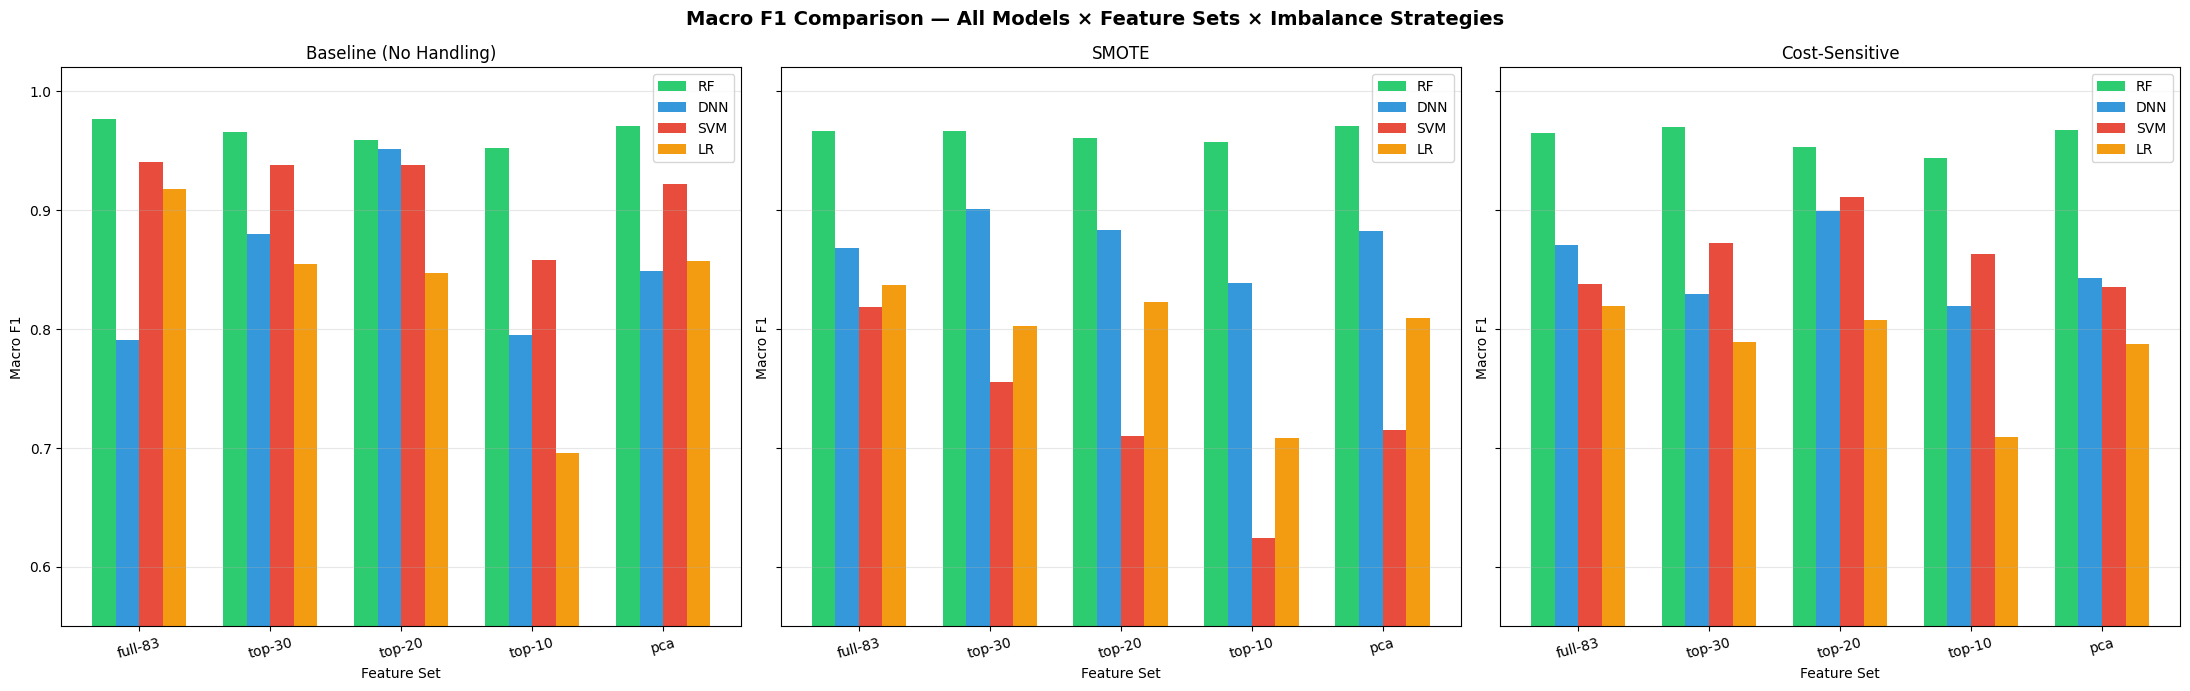

In [12]:
# -- Figure 4: Macro F1 Comparison across all models and imbalance strategies --
# Three subplots: baseline, SMOTE, cost-sensitive
# Each subplot: grouped bars for 4 models across 5 feature sets

fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)

strategies = ["baseline", "smote", "cost-sensitive"]
strategy_titles = ["Baseline (No Handling)", "SMOTE", "Cost-Sensitive"]
models_list = ["RF", "DNN", "SVM", "LR"]
colors = {"RF": "#2ecc71", "DNN": "#3498db", "SVM": "#e74c3c", "LR": "#f39c12"}
fs_order = ["full-83", "top-30", "top-20", "top-10", "pca"]

bar_width = 0.18
x = np.arange(len(fs_order))

for ax, strategy, title in zip(axes, strategies, strategy_titles):
    for i, model in enumerate(models_list):
        vals = []
        for fs in fs_order:
            row = master[(master["model"] == model) & 
                        (master["feature_set"] == fs) & 
                        (master["imbalance"] == strategy)]
            vals.append(row.iloc[0]["macro_f1"] if len(row) > 0 else 0)
        
        ax.bar(x + i * bar_width, vals, bar_width, label=model, color=colors[model])
    
    ax.set_xlabel("Feature Set")
    ax.set_ylabel("Macro F1")
    ax.set_title(title)
    ax.set_xticks(x + bar_width * 1.5)
    ax.set_xticklabels(fs_order, rotation=15)
    ax.set_ylim(0.55, 1.02)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Macro F1 Comparison — All Models × Feature Sets × Imbalance Strategies", 
             fontsize=14, fontweight="bold")
plt.tight_layout()

save_path = os.path.join(figures_dir, "macro_f1_comparison.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()

Saved: /Users/piyushdaga/Desktop/ML/ML-Poject/CS-6140-Project-IoT-Intrusion-Detection/figures/feature_reduction_impact.png


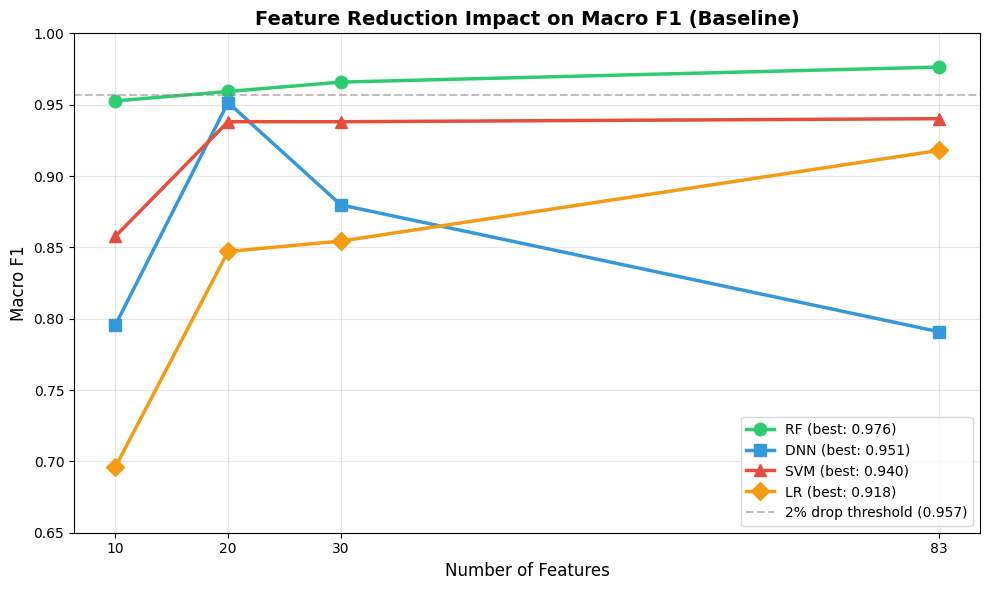

In [13]:
# -- Figure 5: Feature Reduction Impact --
# Line chart: x-axis = number of features, y-axis = macro F1, one line per model
# Uses baseline only for clean comparison
# Shows exactly where performance drops off

feature_counts = {"top-10": 10, "top-20": 20, "top-30": 30, "full-83": 83}
x_vals = [10, 20, 30, 83]
models_list = ["RF", "DNN", "SVM", "LR"]
colors = {"RF": "#2ecc71", "DNN": "#3498db", "SVM": "#e74c3c", "LR": "#f39c12"}
markers = {"RF": "o", "DNN": "s", "SVM": "^", "LR": "D"}

baseline_data = master[master["imbalance"] == "baseline"]

fig, ax = plt.subplots(figsize=(10, 6))

for model in models_list:
    y_vals = []
    for fs in ["top-10", "top-20", "top-30", "full-83"]:
        row = baseline_data[(baseline_data["model"] == model) & (baseline_data["feature_set"] == fs)]
        y_vals.append(row.iloc[0]["macro_f1"] if len(row) > 0 else 0)
    
    ax.plot(x_vals, y_vals, marker=markers[model], linewidth=2.5, markersize=9,
            label=f"{model} (best: {max(y_vals):.3f})", color=colors[model])

# Add 2% drop threshold from RF full-83
rf_full = baseline_data[(baseline_data["model"] == "RF") & (baseline_data["feature_set"] == "full-83")]
rf_best = rf_full.iloc[0]["macro_f1"]
ax.axhline(y=rf_best * 0.98, color="gray", linestyle="--", alpha=0.5, label=f"2% drop threshold ({rf_best*0.98:.3f})")

ax.set_xlabel("Number of Features", fontsize=12)
ax.set_ylabel("Macro F1", fontsize=12)
ax.set_title("Feature Reduction Impact on Macro F1 (Baseline)", fontsize=14, fontweight="bold")
ax.set_xticks(x_vals)
ax.set_xticklabels(["10", "20", "30", "83"])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.65, 1.0)

plt.tight_layout()
save_path = os.path.join(figures_dir, "feature_reduction_impact.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()

Saved: /Users/piyushdaga/Desktop/ML/ML-Poject/CS-6140-Project-IoT-Intrusion-Detection/figures/rare_class_f1_comparison.png


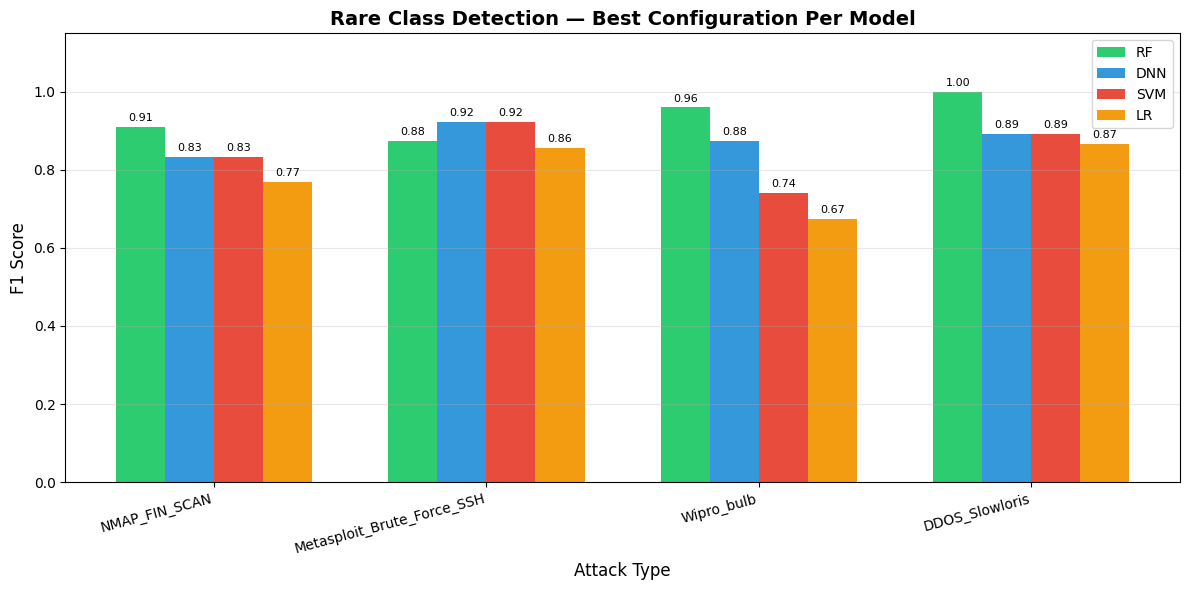

In [16]:
# -- Figure 6: Rare Class F1 across best config per model --
# Shows how each model handles the hardest-to-detect attack types

best_configs = {
    "RF": "rf_full-83_baseline",
    "DNN": "dnn_top-20_baseline",
    "SVM": "svm_full-83_baseline",
    "LR": "lr_full-83_baseline",
}

rare_classes = ["NMAP_FIN_SCAN", "Metasploit_Brute_Force_SSH", "Wipro_bulb", "DDOS_Slowloris"]

# Map numeric indices to class names for DNN reports
class_id_to_name = {str(i): name for i, name in enumerate(class_names)}

colors = {"RF": "#2ecc71", "DNN": "#3498db", "SVM": "#e74c3c", "LR": "#f39c12"}

fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.18
x = np.arange(len(rare_classes))

for i, (model, exp_name) in enumerate(best_configs.items()):
    report_path = os.path.join(results_dir, f"{exp_name}_report.csv")
    df = pd.read_csv(report_path, index_col=0)
    
    # Rename numeric indices to class names if needed (DNN reports)
    df.index = [class_id_to_name.get(str(idx), idx) for idx in df.index]
    
    f1_vals = []
    for cls in rare_classes:
        if cls in df.index:
            f1_vals.append(df.loc[cls, "f1-score"])
        else:
            f1_vals.append(0)
    
    bars = ax.bar(x + i * bar_width, f1_vals, bar_width, label=model, color=colors[model])
    
    for bar, val in zip(bars, f1_vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=8)

ax.set_xlabel("Attack Type", fontsize=12)
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_title("Rare Class Detection — Best Configuration Per Model", fontsize=14, fontweight="bold")
ax.set_xticks(x + bar_width * 1.5)
ax.set_xticklabels(rare_classes, rotation=15, ha="right")
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_path = os.path.join(figures_dir, "rare_class_f1_comparison.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()

Saved: /Users/piyushdaga/Desktop/ML/ML-Poject/CS-6140-Project-IoT-Intrusion-Detection/figures/confusion_matrix_best.png


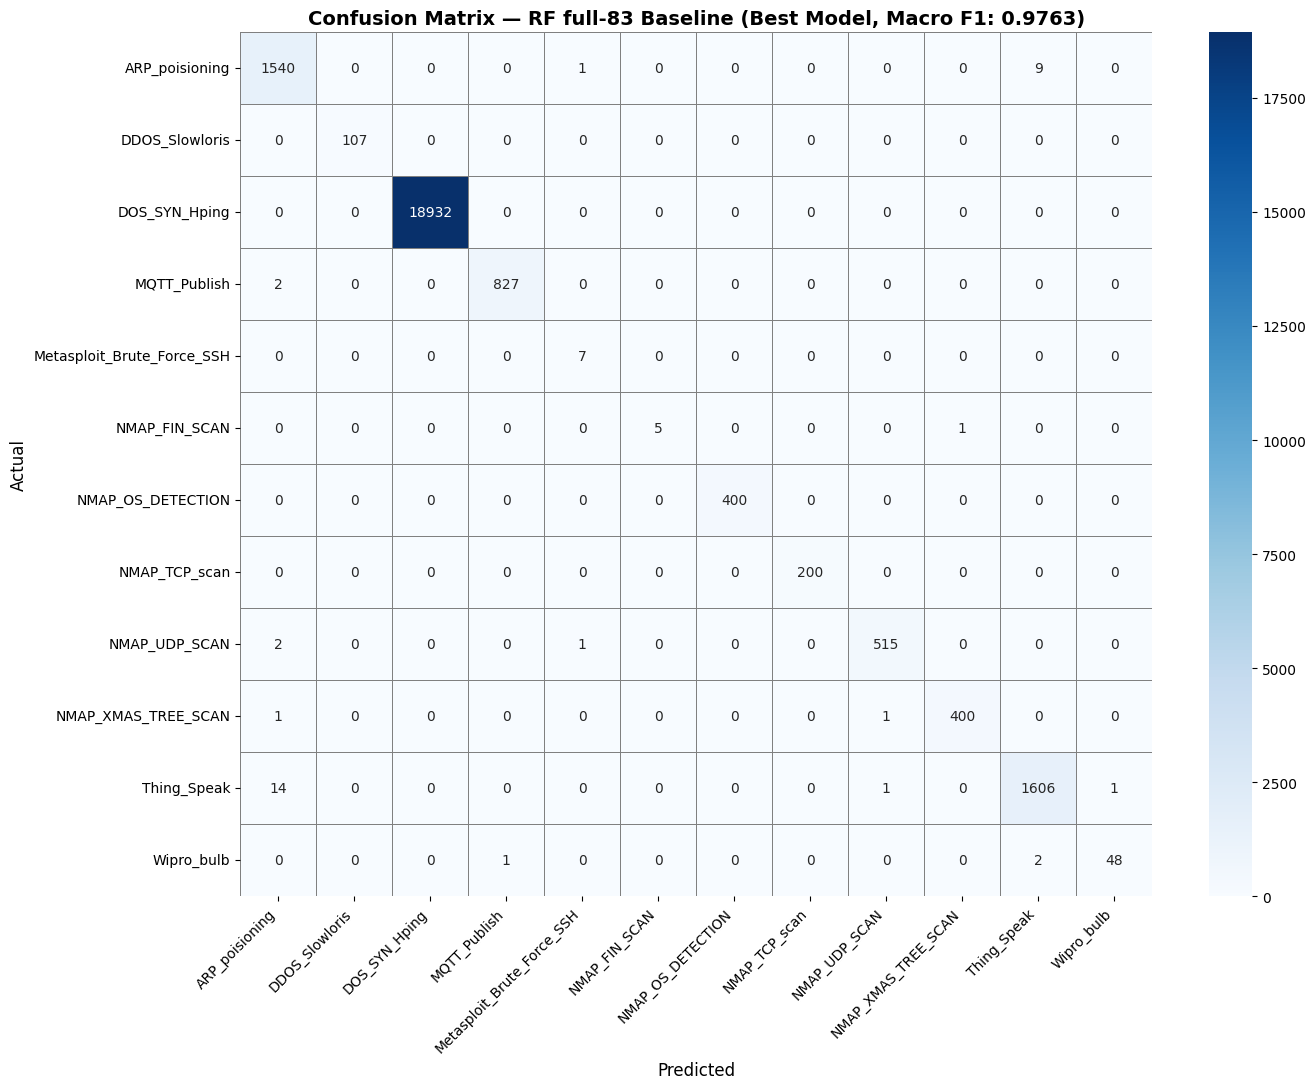

In [15]:
# -- Figure 7: Confusion Matrix for best model (RF full-83 baseline) --
from sklearn.metrics import confusion_matrix

y_pred_best = best_model.predict(X_test_full)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(14, 11))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            linewidths=0.5, linecolor="gray")

ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
ax.set_title("Confusion Matrix — RF full-83 Baseline (Best Model, Macro F1: 0.9763)", 
             fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

save_path = os.path.join(figures_dir, "confusion_matrix_best.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()

  Before SMOTE: 98,493 samples


/Users/piyushdaga/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


  After SMOTE:  908,724 samples
Saved: /Users/piyushdaga/Desktop/ML/ML-Poject/CS-6140-Project-IoT-Intrusion-Detection/figures/smote_comparison.png


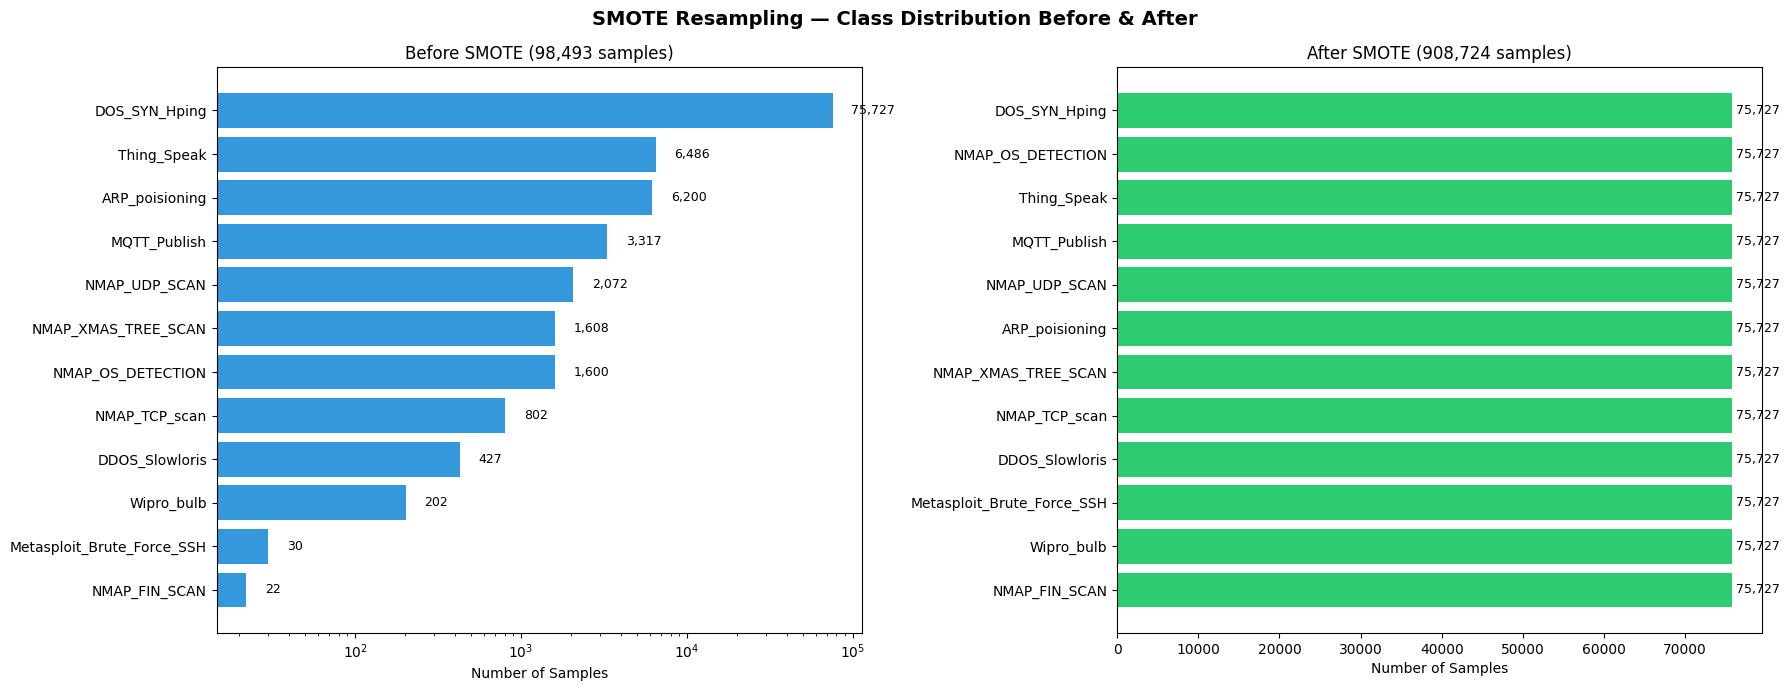

In [17]:
# -- Figure 8: SMOTE Before/After Class Distribution --
from src.preprocessing import apply_smote

X_smote, y_smote = apply_smote(X_train_full, y_train)

before_counts = pd.Series(y_train).map(dict(enumerate(class_names))).value_counts()
after_counts = pd.Series(y_smote).map(dict(enumerate(class_names))).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Before SMOTE
ax1 = axes[0]
bars1 = ax1.barh(before_counts.index[::-1], before_counts.values[::-1], color="#3498db")
ax1.set_xlabel("Number of Samples")
ax1.set_title("Before SMOTE (98,493 samples)")
ax1.set_xscale("log")
for bar, val in zip(bars1, before_counts.values[::-1]):
    ax1.text(bar.get_width() * 1.3, bar.get_y() + bar.get_height()/2,
             f"{val:,}", va="center", fontsize=9)

# After SMOTE
ax2 = axes[1]
bars2 = ax2.barh(after_counts.index[::-1], after_counts.values[::-1], color="#2ecc71")
ax2.set_xlabel("Number of Samples")
ax2.set_title(f"After SMOTE ({len(y_smote):,} samples)")
for bar, val in zip(bars2, after_counts.values[::-1]):
    ax2.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f"{val:,}", va="center", fontsize=9)

plt.suptitle("SMOTE Resampling — Class Distribution Before & After", 
             fontsize=14, fontweight="bold")
plt.tight_layout()

save_path = os.path.join(figures_dir, "smote_comparison.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()

Saved: /Users/piyushdaga/Desktop/ML/ML-Poject/CS-6140-Project-IoT-Intrusion-Detection/figures/imbalance_strategy_comparison.png


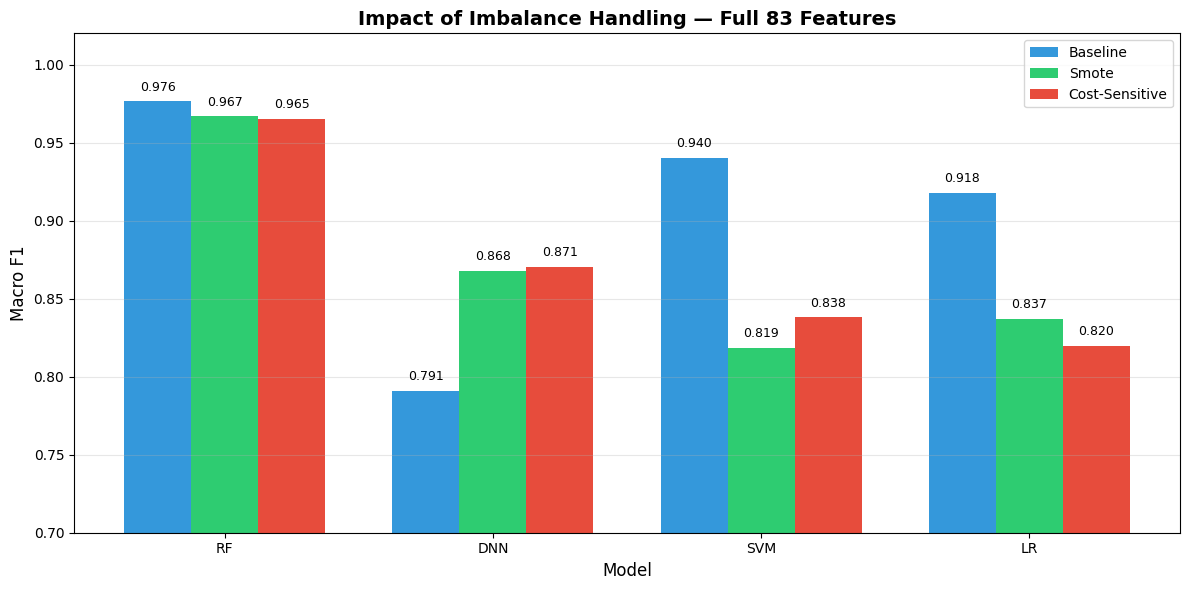



ALL FIGURES SAVED:
  class_distribution.png
  confusion_matrix_best.png
  dnn_loss_full-83_baseline.png
  dnn_loss_full-83_cost-sensitive.png
  dnn_loss_full-83_smote.png
  dnn_loss_pca_baseline.png
  dnn_loss_pca_cost-sensitive.png
  dnn_loss_pca_smote.png
  dnn_loss_top-10_baseline.png
  dnn_loss_top-10_cost-sensitive.png
  dnn_loss_top-10_smote.png
  dnn_loss_top-20_baseline.png
  dnn_loss_top-20_cost-sensitive.png
  dnn_loss_top-20_smote.png
  dnn_loss_top-30_baseline.png
  dnn_loss_top-30_cost-sensitive.png
  dnn_loss_top-30_smote.png
  feature_importance.png
  feature_reduction_impact.png
  imbalance_strategy_comparison.png
  macro_f1_comparison.png
  pca_variance.png
  rare_class_f1_comparison.png
  smote_comparison.png


In [18]:
# -- Figure 9: Imbalance Strategy Comparison per Model --
# For each model, how does baseline vs SMOTE vs cost-sensitive compare?
# Uses full-83 feature set for clean comparison

models_list = ["RF", "DNN", "SVM", "LR"]
strategies = ["baseline", "smote", "cost-sensitive"]
strategy_colors = {"baseline": "#3498db", "smote": "#2ecc71", "cost-sensitive": "#e74c3c"}

full83 = master[master["feature_set"] == "full-83"]

fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.25
x = np.arange(len(models_list))

for i, strategy in enumerate(strategies):
    vals = []
    for model in models_list:
        row = full83[(full83["model"] == model) & (full83["imbalance"] == strategy)]
        vals.append(row.iloc[0]["macro_f1"] if len(row) > 0 else 0)
    
    bars = ax.bar(x + i * bar_width, vals, bar_width, 
                  label=strategy.title(), color=strategy_colors[strategy])
    
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Macro F1", fontsize=12)
ax.set_title("Impact of Imbalance Handling — Full 83 Features", fontsize=14, fontweight="bold")
ax.set_xticks(x + bar_width)
ax.set_xticklabels(models_list)
ax.set_ylim(0.7, 1.02)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
save_path = os.path.join(figures_dir, "imbalance_strategy_comparison.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()

# Print all figures created
print("\n\nALL FIGURES SAVED:")
print("=" * 50)
for f in sorted(os.listdir(figures_dir)):
    if f.endswith(".png"):
        print(f"  {f}")